# **Урок 5**. Семантическая сегментация


На лекции мы с вами углубили свои знания о семантической сегментации: 
- теперь мы знаем не только ```UNet```, но и многие другие архитектуры
- знаем, что для обучения и оценки моделей можно использовать и попиксельные метрики, и метрики на множествах
- а ещё на прошлых практиках мы научились учить модели круто

Давайте сегодня возьмём тот же датасет, что уже был в базовом курсе для задачи сегментации и посмотрим, сможем ли получить на нем лучшее качество, чем раньше.

## **План**

1. Заводим базовый эксперимент с UNet
2. Учим UNet круче
3. Учим не только UNet

Брать модельки можно в [torchvision.models](https://pytorch.org/vision/stable/models.html#semantic-segmentation), но выбирать там особо не из чего. Также есть репозиторий [segmentation_models_pytorch](https://github.com/qubvel-org/segmentation_models.pytorch), где выбора явно больше, вот [табличка с архитектурами](https://github.com/qubvel-org/segmentation_models.pytorch?tab=readme-ov-file#architectures-).

Давайте попробуем второй вариант, так как с первым мы работать уже научились в классификации.

Устанавливаем в окружение репозиторий согласно [инструкции](https://github.com/qubvel-org/segmentation_models.pytorch?tab=readme-ov-file#installation).

In [2]:
%pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
# ставим совместимую версию huggingface
%pip install huggingface_hub==0.24.6

Note: you may need to restart the kernel to use updated packages.


In [6]:
# ставим либу для аугментаций, если её нет
%pip install -U albumentations

Note: you may need to restart the kernel to use updated packages.


## **1. Заводим базовый эксперимент с UNet**

Вспомним, что уже было. 

В качестве датасета у нас был [```NYUv2```](https://paperswithcode.com/dataset/nyuv2) - сет с различными indoor фото. В качестве модели использовали ```UNet```, оптимизировали попиксельную кросс-энтропию, а в качестве метрики качества была ```Pixel Accuracy (PA)``` — просто попиксельная точность. 

Обучая ```UNet```, получили финальную метрику на валидации ```PA = ~34%```. 
Вот эти результаты и будем сегодня бить :)


Скачайте снова датасет по прямой ссылке, если у вас его под рукой нет:

In [7]:
! wget http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat

--2026-05-25 08:44:42--  http://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat
Resolving horatio.cs.nyu.edu (horatio.cs.nyu.edu)... 216.165.22.17
Connecting to horatio.cs.nyu.edu (horatio.cs.nyu.edu)|216.165.22.17|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat [following]
--2026-05-25 08:44:42--  https://horatio.cs.nyu.edu/mit/silberman/nyu_depth_v2/nyu_depth_v2_labeled.mat
Connecting to horatio.cs.nyu.edu (horatio.cs.nyu.edu)|216.165.22.17|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2972037809 (2.8G)
Saving to: ‘nyu_depth_v2_labeled.mat’

nyu_depth_v2_labele 100%[===================>]   2.77G  95.4MB/s    in 31s     

2026-05-25 08:45:13 (92.1 MB/s) - ‘nyu_depth_v2_labeled.mat’ saved [2972037809/2972037809]



In [8]:
import os
import h5py
import tqdm
import wandb
import torch
import random

import numpy as np
import typing as tp
import torch.nn as nn
import matplotlib.pyplot as plt

import segmentation_models_pytorch as smp

from functools import reduce
from torch import optim
from torch.optim import Adam
from dataclasses import dataclass
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

device = 'cuda:1'

In [9]:
# прощаемся с рандомом
# тут всю фиксацию внесла в одну функцию, чтобы поменьше функций звать
def fix_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.cuda.empty_cache()

    
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    
# сразу фиксирую сиды, чтобы разделение выборки воспроизводимо было 
fix_everything(24)

Сделаем препроцессинг датасета, который вы уже тоже видели:

In [10]:
# Напоминание про h5py: https://docs.h5py.org/en/stable/quick.html#quick
data = h5py.File('/kaggle/working/nyu_depth_v2_labeled.mat')

print(data.keys())
print(data['images'])
print(data['labels'])

<KeysViewHDF5 ['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes']>
<HDF5 dataset "images": shape (1449, 3, 640, 480), type "|u1">
<HDF5 dataset "labels": shape (1449, 640, 480), type "<u2">


In [11]:
# Преобразуем в numpy-массив
raw_images, raw_labels = data['images'], data['labels']
all_imgs_np, all_labels_np = np.empty_like(raw_images), np.empty_like(raw_labels)
raw_images.read_direct(all_imgs_np)
raw_labels.read_direct(all_labels_np)

In [12]:
labels_set = set()
for labels in raw_labels:
    labels_set = labels_set.union(set(labels.flatten().tolist()))

len(labels_set)

895

In [13]:
# функция для визуализации
def show_sample(img_np, label_np):
    _, ax = plt.subplots(1, 2, figsize=(10, 8))
    ax[0].imshow(img_np)
    ax[1].imshow(label_np)
    plt.show()

In [14]:
all_labels_np[0].shape

(640, 480)

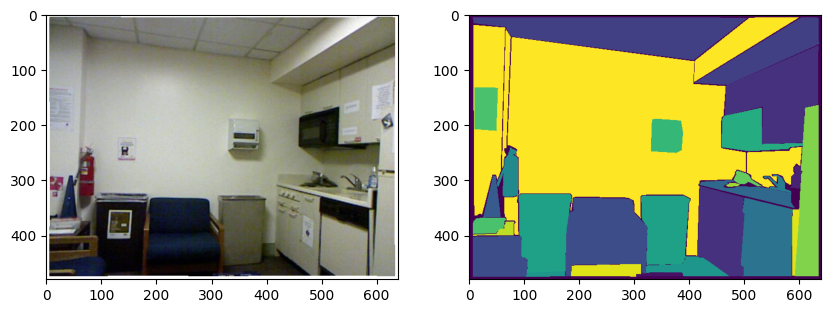

In [15]:
# Смотрим картинку и её маски
show_sample(all_imgs_np[0].transpose((2, 1, 0)), all_labels_np[0].transpose(1, 0))

Из чего при этом у нас состоит маска:

In [16]:
print(all_imgs_np[0].shape)
print(all_labels_np[0].shape)
print(np.unique(all_labels_np[0]))

(3, 640, 480)
(640, 480)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


Как видим, это одноканальный массив того же размера с целыми числами — метками классов на маске. А всего классов 895.

Теперь для этих данных заведём датасет (пока такой же, как и раньше):

In [17]:
class SegmentationDataset(Dataset):
    def __init__(self, img_array, label_array, transforms):
        
        label_array = label_array.astype('int32')
        self.img_array = img_array.transpose((0, 2, 3, 1))
        self.label_array = label_array
        self.transforms = transforms

    def __getitem__(self, index):
        transformed = self.transforms(
            image=self.img_array[index], 
            mask=self.label_array[index]
        )
        return transformed['image'], transformed['mask']

    def __len__(self):
        return len(self.img_array)

In [18]:
# простейший трансформ
transform = A.Compose([
    A.Resize(128, 128), 
    A.ToFloat(max_value=255), 
    ToTensorV2()])

In [19]:
# тут я не стала выделять val/test-части отдельно, а слила вместе в test
indexes_train = np.array(random.sample(range(len(all_imgs_np)), k = int(len(all_imgs_np)*0.8)))
indexes_test = np.array(list(set(range(len(all_imgs_np))) - set(indexes_train)))

In [20]:
# в соответствии с индексами делим ndarrays
train_imgs = all_imgs_np[indexes_train]
train_masks = all_labels_np[indexes_train]

test_imgs = all_imgs_np[indexes_test]
test_masks = all_labels_np[indexes_test]

In [21]:
train_dataset = SegmentationDataset(train_imgs, train_masks, transform)
test_dataset = SegmentationDataset(test_imgs, test_masks, transform)

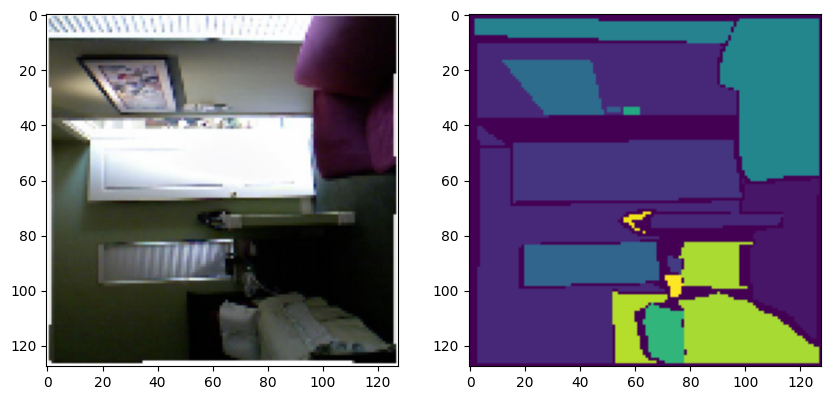

In [22]:
# проверяем, как там картинки с масками
show_sample(test_dataset[0][0].permute((1, 2, 0)), test_dataset[0][1])

In [23]:
print(train_dataset[0][0].shape)
print(train_dataset[0][1].shape)
print(np.unique(train_dataset[0][1]))

torch.Size([3, 128, 128])
torch.Size([128, 128])
[  0   2   3   7   8  11  13  16  21  22  24  26  28  35  75  88 135 141
 172 242 243 262 263 702]


In [24]:
# с этой функцией уже знакомы
def get_scheduler(config, optimizer, loader=None, step=None, gamma=None):
    if config.scheduler_type == 'exp':
        return optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
    elif config.scheduler_type == 'step':
        return optim.lr_scheduler.StepLR(optimizer, step_size=step, gamma=gamma)
    elif config.scheduler_type == 'cosine':
        T_max = config.n_epochs * len(loader) 
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_max)
    else:
        return None

In [25]:
# функция для обучения/тестирования почти такая же, как для классификации
def run_epoch(epoch, net, loader, criterion, optimizer, scheduler, device, is_train):
    if is_train:
        net.train()
    else:
        net.eval()
        
    running_loss = 0.0
    correct = 0
    total = 0
    lr = config.lr

    for i, data in enumerate(loader):
        images, labels = data
        images, labels = images.to(device), labels.to(device)

        outputs = net(images)
        loss = criterion(outputs, labels.long()).mean()

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if (scheduler is not None) and (config.scheduler_type == 'cosine'):
                scheduler.step()
                lr = scheduler.get_last_lr()[0]

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1) # выбираем наиболее вероятный класс для каждого пикселя
        
        correct += (predicted == labels).sum().item() # считаем число правильных предсказаний
        total += reduce(lambda a, b: a * b, labels.shape, 1) # считаем общее число пикселей
    
    acc = correct/total
    
    print('Loss: {:.3f}, Acc: {:.3f}'.format(running_loss / (i + 1), acc * 100.0))
    
    if is_train:
        if (scheduler is not None) and (config.scheduler_type != 'cosine'): 
            scheduler.step()
            lr = scheduler.get_last_lr()[0]
        
        wandb.log({'lr': lr}, step=epoch)    
        wandb.log({'train loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'train acc': acc * 100.0}, step=epoch)
    else:
        wandb.log({'test loss': running_loss / (i + 1)}, step=epoch)
        wandb.log({'test acc': acc * 100.0}, step=epoch)

In [26]:
# конфиг с основными гиперпараметрами
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 10
    lr: float = 1e-4
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = None

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

# и лоадеры для датасетов
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=4,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

test_loader = DataLoader(test_dataset, batch_size=config.batch_size, 
                         shuffle=False, num_workers=4, pin_memory=True)

И для начала давайте в качестве модели возьмём ```UNet``` c [энкодером](https://github.com/qubvel-org/segmentation_models.pytorch?tab=readme-ov-file#encoders-) ```resnet50```:

In [ ]:
# дока https://smp.readthedocs.io/en/latest/models.html#id17
model = smp.Unet(
    encoder_name='resnet50',        # выбираем энкодер из доступных
    encoder_weights='imagenet',     # инициализация
    in_channels=3,                  # 1 — grayscale images, 3 — RGB
    classes=895,                    # сколько будет выходных фичемап
)

In [ ]:
model

In [ ]:
model = model.to(device)
optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer)

In [ ]:
for i, data in enumerate(train_loader):
    images, labels = data
    images, labels = images.to(device), labels.to(device)
    break

In [ ]:
outputs = model(images)

In [ ]:
labels[0]

In [ ]:
outputs.shape

In [ ]:
wandb.init(project='lesson-5', name='unet_resnet50')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Обучение выглядит стабильно, на тесте мы получили ```PA ~ 40%```, что уже на `6 п.п.` больше, чем было в базовом курсе (у нас тут всё-таки энкодер обученный уже, ещё и `resnet50`!) 

Воодушевлённые успехом, давайте посмотрим на визуализацию инференса на тесте:

In [27]:
@torch.inference_mode()
def visualize(model, batch, device):
    model.eval()
    xs, ys = batch
    xs, ys = xs[:3], ys[:3]
    for i, (x, y) in enumerate(zip(xs, ys)):
        prediction = model(x[None, ...].to(device)).cpu().squeeze(0).max(dim=0)[1]

        fig, ax = plt.subplots(1, 3, figsize=(24, 8), facecolor="white")

        ax[0].imshow(x.permute((1, 2, 0)))
        ax[1].imshow(y.to(torch.uint8))
        ax[2].imshow(prediction.to(torch.uint8))

        ax[0].axis("off")
        ax[1].axis("off")
        ax[2].axis("off")
        plt.subplots_adjust(wspace=0, hspace=0.1)
        plt.show()

        if i >= 9:
            break

In [ ]:
batch = next(iter(test_loader))
visualize(model, batch, device=device)

Выглядит, на мой взгляд, не очень воодушевляюще. 

Модель как-то очень примерно угадывает, только самые крупные объекты в кадре — отсюда и `PA` неплохая, пикселей-то таких много, однако абсолютное большинство классов она не понимает.

В общем, явно есть куда расти, этим и займёмся.

## **2. Учим UNet круче**

Какие первые идеи приходят в голову:

- судя по графикам, модель ещё активно учится, `10` эпох ей маловато, надо увеличить
- можно попробовать другие варианты претрейна и энкодера
- мы же умеем настраивать `lr`, может, ему не хватает расписания

Пойдём по порядку. Сперва учим дольше, попробуем в `1,5` раза обучение удлиннить:

In [ ]:
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15 # изменили только число эпох
    lr: float = 1e-4
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = None

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=4,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [ ]:
model = smp.Unet(encoder_name='resnet50', encoder_weights='imagenet', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer)

In [ ]:
wandb.init(project='lesson-5', name='unet_resnet50_15ep')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Окей, стало чуть получше — на `1.2%`. Судя по графикам обучения, модель выходит на плато, а нам бы хотелось побольше прирост увидеть — значит, надо дать ей буст.

Перенесём сюда наши знания из классификации и попробуем использовать `cosine`-шедулер на `lr`, а сам `lr` значительно увеличим - прям в `10` раз. 

In [ ]:
# конфиг с основными гиперпараметрами
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    img_size: int = 128
    n_epochs: int = 15
    lr: float = 1e-3 # увеличили
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine' # а тут выбрали шедулер

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=4,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [ ]:
model = smp.Unet(encoder_name='resnet50', encoder_weights='imagenet', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [ ]:
wandb.init(project='lesson-5', name='unet_resnet50_15ep_cos_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Вот это да, почти до `50%` добрались. Да и график обучения стал значимо другим — он сразу довольно сильно падает и мы видим с самого начала результаты выше.

А было бы так же хорошо, если бы только большой `lr` использовали, без косинуса?

In [ ]:
# конфиг с основными гиперпараметрами
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = None

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=12,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [ ]:
model = smp.Unet(encoder_name='resnet50', encoder_weights='imagenet', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [ ]:
wandb.init(project='lesson-5', name='unet_resnet50_15ep_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Результат тоже хороший — мы видим не такой провал, как в классификации с большим `lr` без снижения, а в начале обучения графики вообще совпадают. Но финально результат всё же хуже чем с косинусом, при этом он заметно менее стабильный — провалился в самом конце почти на `1 п.п.`.

Тогда давайте зафиксируем стратегию `cosine` + `lr=1e3` и попробуем взять для `UNet` другой энкодер (а декодер останется таким же), ведь на `Resnet`-ах свет клином не сошёлся. 

Посмотрим, какие модели у нас есть в [репозитории](https://github.com/qubvel-org/segmentation_models.pytorch?tab=readme-ov-file#-models-). Так как я лично очень люблю `efficientnet-b4`, давайте попробуем её:

In [ ]:
import gc

del model
del optimizer
del batch  # если есть большие тензоры

gc.collect()
torch.cuda.empty_cache()

In [29]:
# конфиг с основными гиперпараметрами
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

In [30]:
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=4,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [33]:
model = smp.Unet(encoder_name='mobileone_s4', encoder_weights='imagenet', in_channels=3, classes=895) # заменили энкодер
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [34]:
# device = "cuda:0"
wandb.init(project='lesson-5', name='unet_mobileone_s4_15ep_cos_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 15
Loss: 4.986, Acc: 27.960
Validation
Loss: 3.549, Acc: 37.558
----------------------
Training epoch:  2 / 15
Loss: 2.926, Acc: 37.939
Validation
Loss: 2.684, Acc: 39.625
----------------------
Training epoch:  3 / 15
Loss: 2.550, Acc: 40.015
Validation
Loss: 2.603, Acc: 41.551
----------------------
Training epoch:  4 / 15
Loss: 2.354, Acc: 43.643
Validation
Loss: 2.453, Acc: 43.433
----------------------
Training epoch:  5 / 15
Loss: 2.178, Acc: 47.091
Validation
Loss: 2.345, Acc: 45.319
----------------------
Training epoch:  6 / 15
Loss: 2.031, Acc: 50.609
Validation
Loss: 2.260, Acc: 47.941
----------------------
Training epoch:  7 / 15
Loss: 1.876, Acc: 54.459
Validation
Loss: 2.208, Acc: 49.383
----------------------
Training epoch:  8 / 15
Loss: 1.742, Acc: 57.662
Validation
Loss: 2.165, Acc: 49.616
----------------------
Training epoch:  9 / 15
Loss: 1.622, Acc: 60.368
Validation
Loss: 2.107, Acc: 51.076
----------------------
Training epoch:  10 / 15
Los

lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
test acc,▁▂▃▄▅▆▇▇▇██████
test loss,█▄▃▃▂▂▂▁▁▁▁▁▁▁▁
train acc,▁▃▃▄▄▅▆▆▇▇▇████
train loss,█▄▃▃▃▂▂▂▂▁▁▁▁▁▁
lr,0
test acc,51.97735
test loss,2.10216
train acc,67.48461
train loss,1.35687


Замечательно! Медленно, но верно, мы растём и снова поднялись на `1 п.п.` — теперь перевалили за `51%`.

Подведём небольшие итоги:
- учить дольше круче (снова)
- использовать `cosine` с большим `lr` круче (снова)
- `EfficientNet` показывает лучше результаты, чем `ResNet` (снова)

Пока все наши знания успешно переносятся с классификации на сегментацию, даже скучно.

Давайте разнообразим нашу жизнь и попробуем отойти от архитектуры `UNet`.

## 2025.05.25 
efficientnet-b4 не влезла на T4. Вместо нее взял mobileone-s4. +1.5 пп на тесте к resnet-50

## **3. Учим не только UNet**

Сперва сильно далеко уходить не будем и попробуем `UNet++` — вариант сети с более сложным декодером.

<p align="center">
  <a href="images/unet_plus.png"><img src="images/unet_plus.png" style="width:50%;"/></a>
</p>

In [42]:
# тут ничего не трогаем
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=4,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [43]:
# а вот тут у нас будет Unet++, а не UNet, подменяется влёгкую
# дока https://smp.readthedocs.io/en/latest/models.html#unetplusplus
model = smp.UnetPlusPlus(encoder_name='mobileone_s4', encoder_weights='imagenet', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [44]:
wandb.init(project='lesson-5', name='unet++_mobileone_s4_15ep_cos_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 15
Loss: 4.961, Acc: 26.895
Validation
Loss: 3.522, Acc: 36.063
----------------------
Training epoch:  2 / 15
Loss: 2.947, Acc: 36.894
Validation
Loss: 2.882, Acc: 35.619
----------------------
Training epoch:  3 / 15
Loss: 2.581, Acc: 39.781
Validation
Loss: 2.544, Acc: 42.145
----------------------
Training epoch:  4 / 15
Loss: 2.359, Acc: 44.077
Validation
Loss: 2.386, Acc: 44.687
----------------------
Training epoch:  5 / 15
Loss: 2.176, Acc: 47.026
Validation
Loss: 2.351, Acc: 46.728
----------------------
Training epoch:  6 / 15
Loss: 1.998, Acc: 52.142
Validation
Loss: 2.277, Acc: 48.229
----------------------
Training epoch:  7 / 15
Loss: 1.847, Acc: 55.159
Validation
Loss: 2.169, Acc: 49.945
----------------------
Training epoch:  8 / 15
Loss: 1.722, Acc: 58.117
Validation
Loss: 2.158, Acc: 50.775
----------------------
Training epoch:  9 / 15
Loss: 1.595, Acc: 61.503
Validation
Loss: 2.099, Acc: 51.628
----------------------
Training epoch:  10 / 15
Los

lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
test acc,▁▁▄▅▆▆▇▇███████
test loss,█▅▃▃▂▂▁▁▁▁▁▁▁▁▁
train acc,▁▃▃▄▄▅▆▆▇▇▇████
train loss,█▄▃▃▃▂▂▂▂▁▁▁▁▁▁
lr,0
test acc,52.12137
test loss,2.06461
train acc,68.91114
train loss,1.30632


Класс, поднялись на `1 п.п.` относительно базовой `UNet`, уже чувствуем себя великими.

Теперь давайте попробуем признаки с разных уровней переагрегировать — использовать `Feature Pyramod Network (FPN)`.

Вот так она выглядит по сравнению с `UNet`:

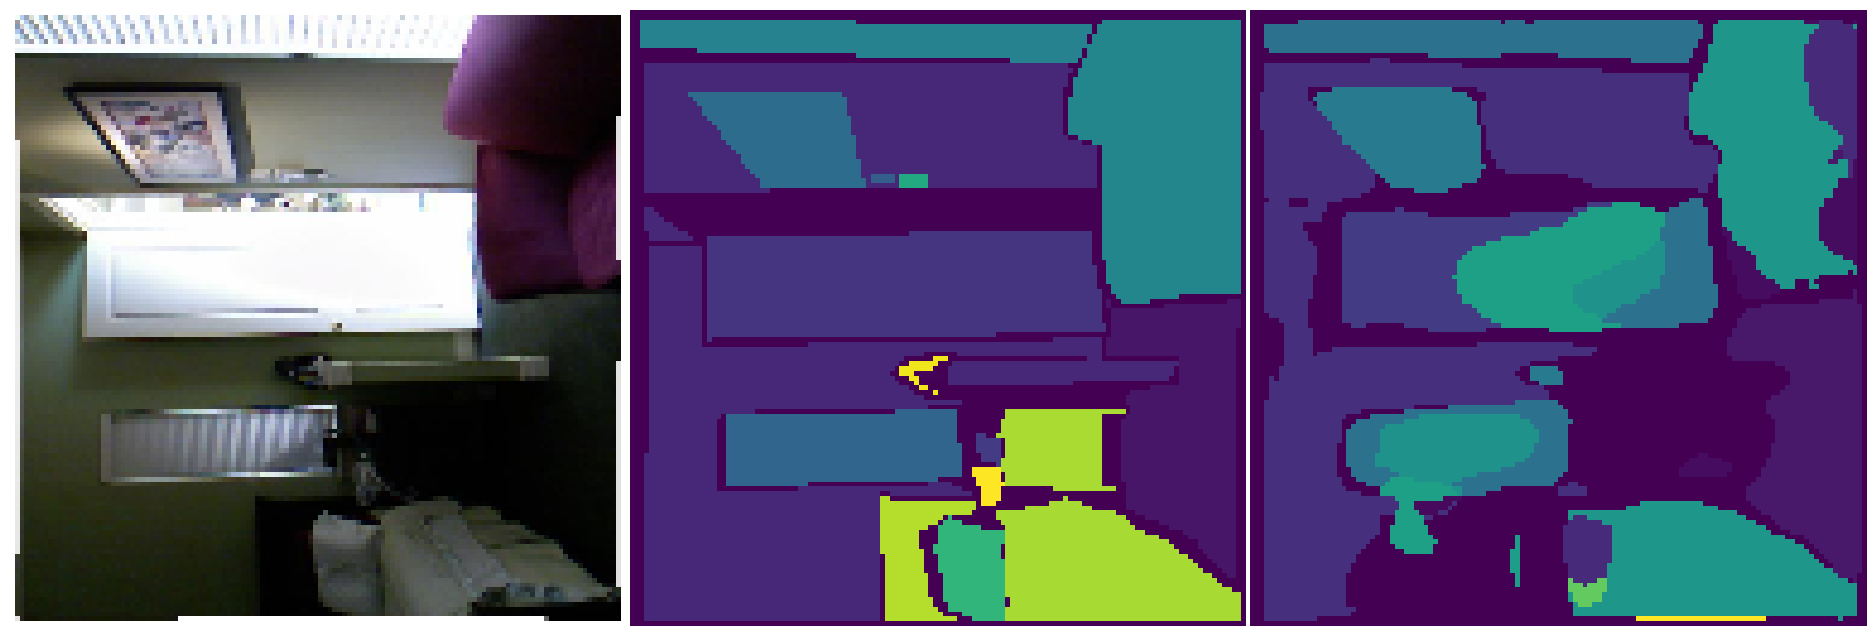

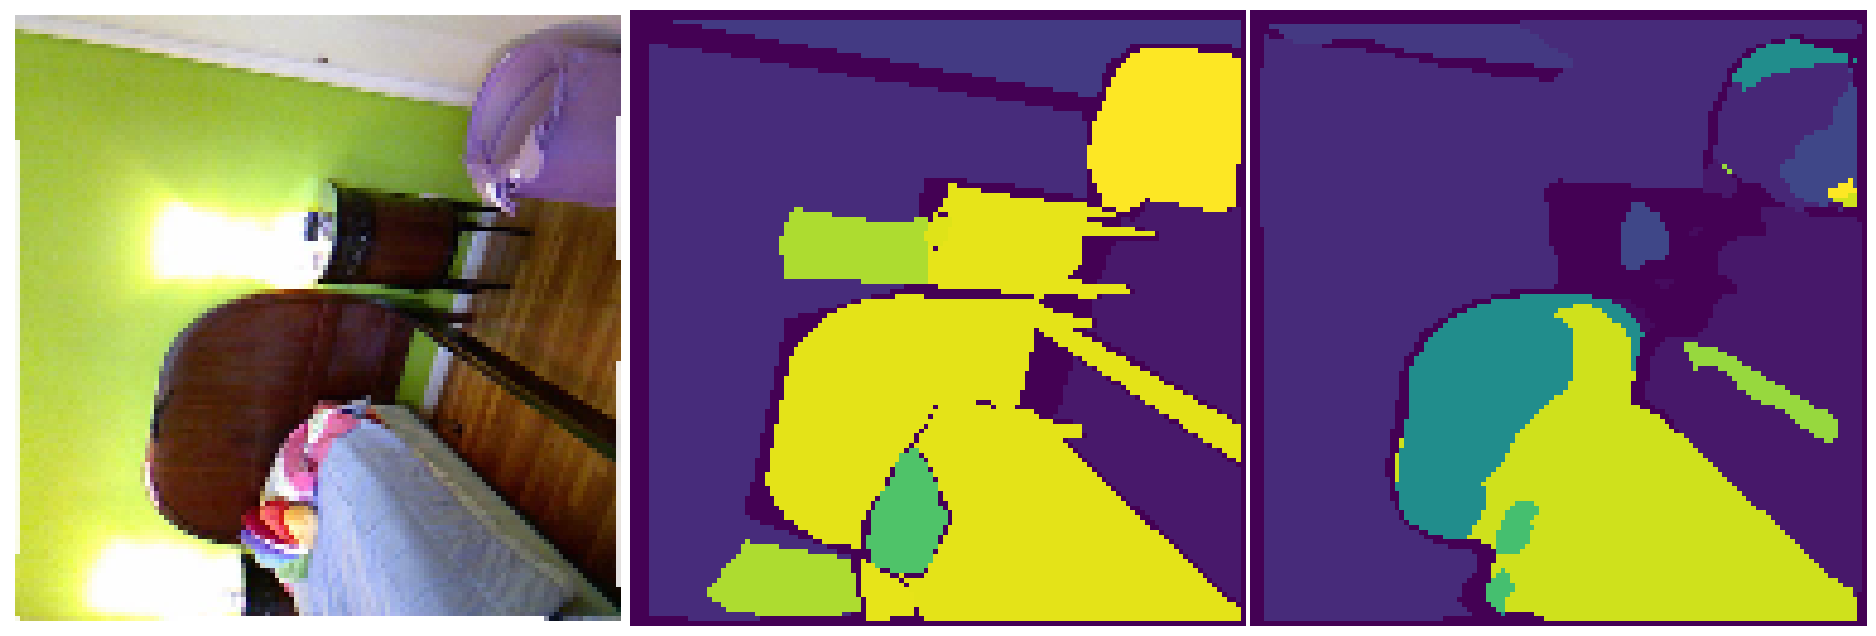

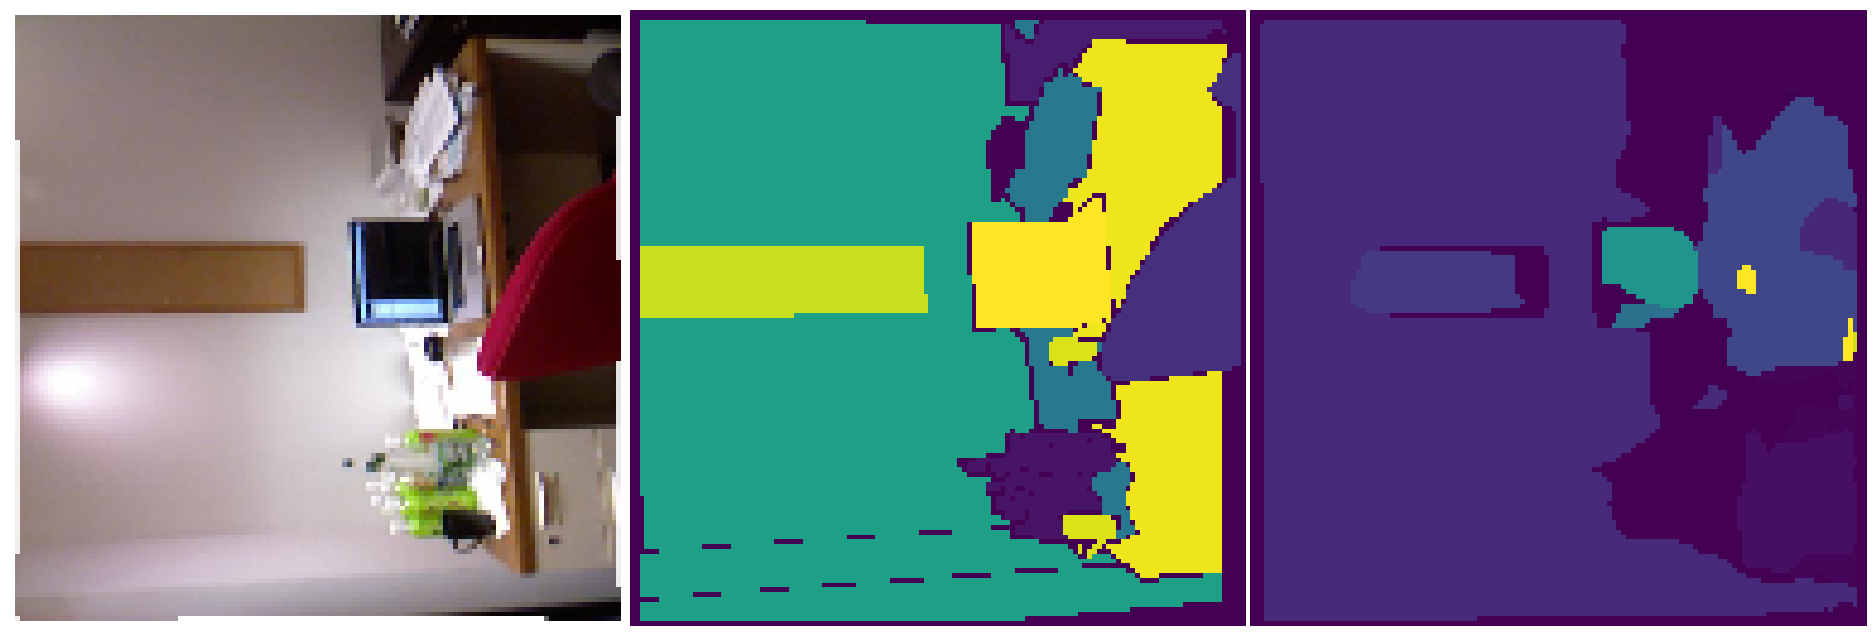

In [46]:
batch = next(iter(test_loader))
visualize(model, batch, device=device)

<p align="center">
  <a href="images/fpn.png"><img src="images/fpn.png" style="width:80%; height:50%;"/></a>
</p>

In [55]:
# тут ничего не трогаем
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 1
    n_epochs: int = 15
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=4,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [56]:
# а вот тут у нас будет FPN, а не UNet
# дока https://smp.readthedocs.io/en/latest/models.html#fpn
model = smp.FPN(encoder_name='resnet50', encoder_weights='imagenet', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [57]:
wandb.init(project='lesson-5', name='fpn_resnet50_15ep_cos_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Training epoch:  1 / 15
Loss: 2.999, Acc: 33.092
Validation


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.75 GiB. GPU 0 has a total capacity of 14.56 GiB of which 303.81 MiB is free. Including non-PyTorch memory, this process has 14.26 GiB memory in use. Of the allocated memory 14.02 GiB is allocated by PyTorch, and 125.92 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

Ну всё, ракета нашего обучения полетела в космос. Надеюсь, после этого вы оценили всю мощь агрегации признаков, ведь мы почти до `58%` дошли!

Давайте ещё проверим будет ли разница между различной реализацией мерджа признаков при их агрегации в декодере `FPN` - через сложение или конкатенацию. 

In [ ]:
# тут ничего не трогаем
@dataclass
class Config:
    seed: int = 24
    batch_size: int = 32
    n_epochs: int = 15
    lr: float = 1e-3
    scheduler_type: tp.Literal['exp', 'step', 'cosine'] | None = 'cosine'

config = Config()
fix_everything(config.seed)

generator = torch.Generator()
generator.manual_seed(config.seed)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, num_workers=12,  
                          shuffle=True, pin_memory=True, drop_last=True, 
                          worker_init_fn=seed_worker, generator=generator)

In [ ]:
# изменим только decoder_merge_policy
# дока https://smp.readthedocs.io/en/latest/models.html#fpn
model = smp.FPN(encoder_name='efficientnet-b4', encoder_weights='imagenet', decoder_merge_policy='cat', in_channels=3, classes=895)
model = model.to(device)

optimizer = Adam(model.parameters(), lr=config.lr)
criterion = nn.CrossEntropyLoss(reduction='none')
scheduler = get_scheduler(config, optimizer, train_loader)

In [ ]:
wandb.init(project='lesson-5', name='fpn_cat_efficientnet-b4_15ep_cos_1e3')

# и погнали учиться
for epoch in range(config.n_epochs):
    print("Training epoch: ", epoch + 1, "/", config.n_epochs)
    run_epoch(epoch, model, train_loader, criterion, optimizer, scheduler, device, is_train=True)

    print('Validation')
    with torch.no_grad():
        run_epoch(epoch, model, test_loader, criterion, optimizer, scheduler, device, is_train=False)
    print('----------------------')

print('Finished training! Enjoy your results!')

wandb.finish()

Как видим, конкатенация, а не складывание признаков, даёт ещё чуть лучший результат — но и учились мы подольше, так как обрабатывать надо большее число фичей. Зато `58.2%` точности получили, ай да мы.

В целом по сравнению с классификацией метрики здесь далеко не так высоки. Но это нормально, сегментация как задача, и конкретно этот датасет очень сложны. Неудивительно, что мы за 5-10 минут обучения не получаем на нём `SOTA`-результаты.

Давайте посмотрим, будет ли визуально заметно, как мы выросли с `40%` до `58%` точности:

In [ ]:
batch = next(iter(test_loader))
visualize(model, batch, device=device)

В целом, да, на первых двух картинках пятна классов лучше оформились :)

Итак,
- `UNet++` c более мощным декодером ещё чуть накидывает точности сегментации
- `FPN` даёт огромный прирост качества 
- причём использовать `concat` признаков в пирамиде будет чуть эффективнее
- не забываем при этом, что `FPN` тяжелее `UNet` и будет работать подольше

Зато мы можем очень сильно порадоваться точности её работы, этим и занимаемся, пока подводим итоги.

## **Итоги**

В этой практике мы:

- провели эксперимент на `NYUv2` без самописного `UNet`-а
- перенесли некоторые свои знания из эффективного обучения моделей классификации на сегментацию и получили улучшения!
- протестировали разные бэкбоны для `UNet`-а, и снова увидели, что `EfficientNet` — супер
- кроме `UNet`, провели эксперименты с `FPN` и оценили, как мощна агрегация признаков

При этом мы много чего не успели попробовать - например, варьировать аугментации данных, использовать лоссы на множествах и комбинировать разные их типы. И у тебя будет классная возможность погрузиться в эти вопросы в ДЗ. 

Ну а мы продолжим практику работой с суперской фундаментальной моделью — `Segment Anything (SAM)`.